# Does paying more lead to higher satisfaction?

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.linear_model import  LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (10, 6)

sns.set_theme(style="whitegrid")

product = pd.read_csv(
    "/Users/gabrielaslomiany/PycharmProjects/Sephora/data/processed/cleaned_product_info.csv",
    engine="python"
)

In [3]:
product.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'ingredients', 'price_usd',
       'limited_edition', 'new', 'online_only', 'out_of_stock',
       'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count'],
      dtype='object')

### Checking relationship between price payed for product and high rating
Columns to keep:

In [26]:
df = product[['rating', 'price_usd', 'reviews', 'loves_count',
    'primary_category', 'secondary_category',
    'limited_edition', 'new', 'online_only', 'sephora_exclusive']]
df.head()

,rating,price_usd,reviews,loves_count,primary_category,secondary_category,limited_edition,new,online_only,sephora_exclusive
0,3.64,35.0,11.0,6320,Fragrance,Value & Gift Sets,False,False,True,False
1,4.15,195.0,13.0,3827,Fragrance,Women,False,False,True,False
2,4.25,195.0,16.0,3253,Fragrance,Women,False,False,True,False
3,4.48,195.0,21.0,3018,Fragrance,Women,False,False,True,False
4,3.23,195.0,13.0,2691,Fragrance,Women,False,False,True,False


In [27]:
df.dtypes

rating                float64
price_usd             float64
reviews               float64
loves_count             int64
primary_category       object
secondary_category     object
limited_edition          bool
new                      bool
online_only              bool
sephora_exclusive        bool
dtype: object

In [29]:
df.isna().sum()

rating                0
price_usd             0
reviews               0
loves_count           0
primary_category      0
secondary_category    0
limited_edition       0
new                   0
online_only           0
sephora_exclusive     0
dtype: int64

## Part 1: Linear Regression Model

In [45]:
feature_cols = ['price_usd', 'loves_count', 'primary_category', 'secondary_category']

X = df[feature_cols]
X = pd.get_dummies(X, columns=['primary_category', 'secondary_category'], drop_first=True, dtype=int)

y = df['rating']
weights = df['reviews']

In [38]:
df[feature_cols].isna().sum()

price_usd             0
loves_count           0
primary_category      0
secondary_category    0
dtype: int64

In [58]:
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42)

#### Why using weights
A product with 500 reviews averaging 4.2 is a solid estimate; a product with 2 reviews averaging 5.0 could easily have been a 3.5 with a slightly different sample. If both are used in the regression as equals, that second product contributes pure noise but counts just as much as the well-supported one.

In [76]:
lr = LinearRegression()
lr.fit(X, y, sample_weight=weights)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [78]:
import warnings

cv = KFold(n_splits=5, shuffle=True, random_state=42)

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    cv_results = cross_validate(
        LinearRegression(), X, y,
        cv=cv,
        scoring=['r2', 'neg_mean_squared_error'],
        params={'sample_weight': weights},
    )

In [79]:
r2_scores = cv_results['test_r2']
print(f"R^2 per fold: {np.round(r2_scores, 4)}")
print(f"R^2 (5-fold CV): {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

R^2 per fold: [-0.0114  0.0091  0.0015 -0.0258  0.0009]
R^2 (5-fold CV): -0.0052 ± 0.0122


In [88]:
# Coefficients: which features move rating, and by how much?
coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)
coef_table.head()

,feature,coefficient
30,secondary_category_Shampoo & Conditioner,0.347210
21,secondary_category_Hair Styling & Treatments,0.303725
7,primary_category_Tools & Brushes,0.261380
5,primary_category_Men,0.215217
26,secondary_category_Men,0.189332


In [89]:
mse_scores = -cv_results['test_neg_mean_squared_error']
rmse_scores = np.sqrt(mse_scores)

print(f"MSE (5-fold CV): {mse_scores.mean():.4f} ± {mse_scores.std():.4f}")
print(f"RMSE (5-fold CV): {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

MSE (5-fold CV): 0.2527 ± 0.0163
RMSE (5-fold CV): 0.5024 ± 0.0162


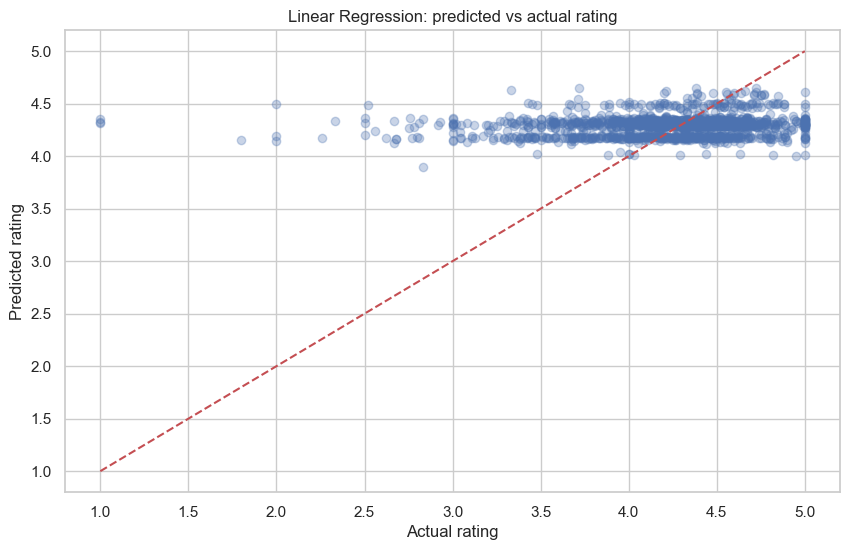

In [83]:
# Predicted vs actual
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual rating')
plt.ylabel('Predicted rating')
plt.title('Linear Regression: predicted vs actual rating')
plt.show()

**Conclusion:** Predicted ratings cluster tightly around 4.0–4.5 regardless of the actual rating, which ranges from 1.0 to 5.0. The model isn't distinguishing between low- and high-rated products — it's essentially predicting close to the average rating for almost everything. Points for low actual ratings sit far above the diagonal (model overpredicts) and points for high actual ratings sit below it (model underpredicts). This visually confirms the near-zero R²: price and the other features included don't carry enough signal to explain variation in product rating.

In [90]:
scores_df = pd.DataFrame({
    'Metric': ['R^2', 'MSE', 'RMSE'],
    'Train/Test Split': [r2, mse, rmse],
    '5-Fold CV Mean': [r2_scores.mean(), mse_scores.mean(), rmse_scores.mean()],
})
scores_df

,Metric,Train/Test Split,5-Fold CV Mean
0,R^2,-0.011387,-0.005158
1,MSE,0.246536,0.252710
2,RMSE,0.496524,0.502443


In [86]:
print(f"\nIntercept (full-data fit): {lr.intercept_:.4f}")
print(f"Coefficient (price_usd): {lr.coef_[0]:.4f}")


Intercept (full-data fit): 4.2452
Coefficient (price_usd): 0.0005


In [92]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train, sample_weight=weights_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5

mse_scores_rf = -cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_scores_rf = mse_scores_rf ** 0.5
r2_scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')

In [94]:
scores_df = pd.DataFrame({
    'Model': ['Linear Regression'] * 3 + ['Random Forest'] * 3,
    'Metric': ['R^2', 'MSE', 'RMSE'] * 2,
    'Train/Test Split': [r2, mse, rmse, r2_rf, mse_rf, rmse_rf],
    '5-Fold CV Mean': [
        r2_scores.mean(), mse_scores.mean(), rmse_scores.mean(),
        r2_scores_rf.mean(), mse_scores_rf.mean(), rmse_scores_rf.mean()
    ]
})
scores_df

,Model,Metric,Train/Test Split,5-Fold CV Mean
0,Linear Regression,R^2,-0.011387,0.020809
1,Linear Regression,MSE,0.246536,0.245928
2,Linear Regression,RMSE,0.496524,0.495639
3,Random Forest,R^2,-0.118844,-0.116226
4,Random Forest,MSE,0.272730,0.280389
5,Random Forest,RMSE,0.522236,0.529166


In [96]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
importance_df.head(10)

,feature,importance
1,loves_count,0.530852
0,price_usd,0.271879
19,secondary_category_Face,0.025547
17,secondary_category_Eye,0.020503
15,secondary_category_Cheek,0.009721
26,secondary_category_Men,0.009489
4,primary_category_Makeup,0.008768
16,secondary_category_Cleansers,0.008689
36,secondary_category_Treatments,0.008278
34,secondary_category_Sunscreen,0.007877


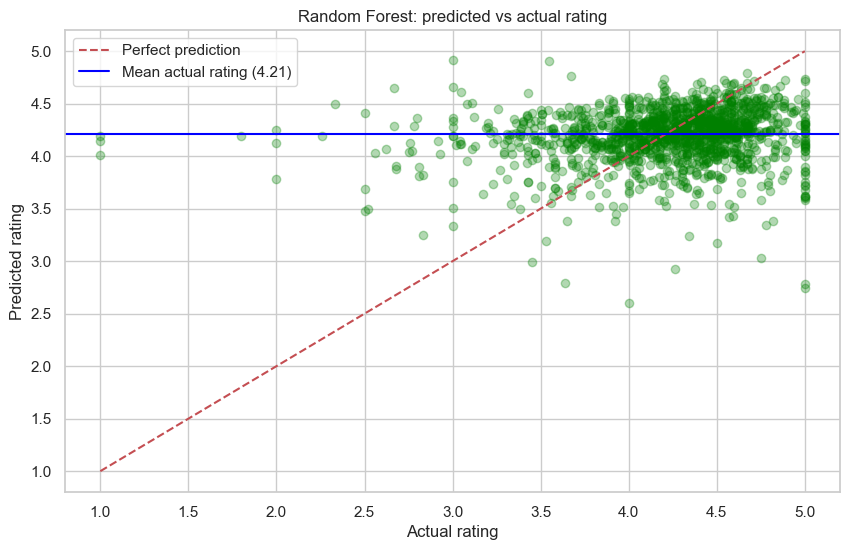

In [103]:
# Predicted vs actual — Random Forest
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.axhline(y_test.mean(), color='blue', linestyle='-', label=f'Mean actual rating ({y_test.mean():.2f})')
plt.xlabel('Actual rating')
plt.ylabel('Predicted rating')
plt.title('Random Forest: predicted vs actual rating')
plt.legend()
plt.show()

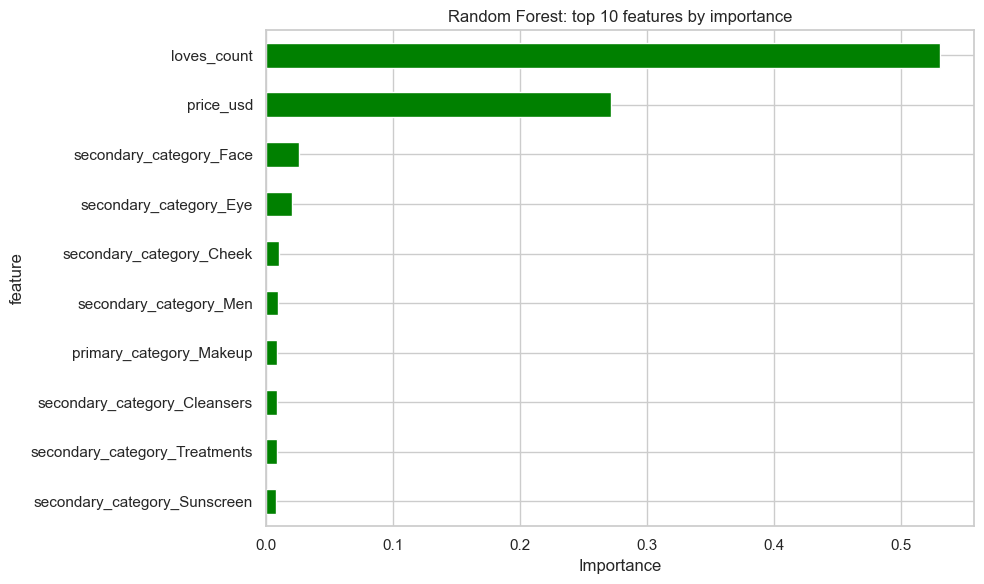

In [101]:
top_n = 10
importance_df.tail(top_n).plot(
    kind='barh', x='feature', y='importance', color='green', legend=False
)
plt.xlabel('Importance')
plt.title(f'Random Forest: top {top_n} features by importance')
plt.tight_layout()
plt.show()

### Conclusion — Random Forest vs. Linear Regression

Random Forest performs slightly worse than Linear Regression on every metric, both on the train/test split and the 5-fold CV mean (R²: -0.119 vs. -0.011; MSE: 0.273 vs. 0.247; RMSE: 0.522 vs. 0.497). Since both models land at or below R²=0, adding nonlinear flexibility didn't uncover hidden structure — if anything it made things slightly worse, likely by overfitting to noise in the training data. This suggests the weak relationship found earlier isn't due to nonlinearity; the features simply don't carry much signal for predicting rating.

Feature importance confirms `loves_count` and `price_usd` are the most influential inputs, with the one-hot encoded category features contributing comparatively little.

The predicted-vs-actual plot tells the same story as the linear model: predictions cluster tightly around the mean actual rating (~4.2) regardless of a product's true rating, rather than tracking the diagonal. In other words, the model's best strategy is close to "always guess near the average" — reinforcing that price and popularity alone are weak predictors of product satisfaction.